# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
random_state = 3090 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import numpy as np
import joblib

In [3]:
# Загрузка данных
try:
    df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
    print("Данные загружены из /datasets/")
except:
    df = pd.read_csv('coffee_churn_dataset.csv', sep=',', decimal='.')
    print("Данные загружены локально")

Данные загружены локально


## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [4]:
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

Размер датасета: (10450, 27)

Первые 5 строк:


,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [5]:
print("\nИнформация о колонках и типах данных:")
df.info()


Информация о колонках и типах данных:
<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 no

In [6]:
print("\nСтатистическое описание числовых признаков:")
display(df.describe())


Статистическое описание числовых признаков:


,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [7]:
print("\nПроверка на пропуски:")
print(df.isnull().sum())


Проверка на пропуски:
user_id                       0
days_since_last_order       945
order_frequency_month       600
order_frequency_week        388
avg_order_value             583
median_order_value          831
total_spent_last_month      294
total_spent_last_week       944
discount_usage_rate         397
last_coffee_type            258
preferred_roast             116
milk_preference             668
seasonal_menu_tried         989
coffee_bean_origin          682
last_drink_size             504
subscription_status         938
app_opens_per_week          896
notifications_enabled       537
review_rating_last_10       693
review_rating_last_1        857
app_crashes_last_month      721
seasons                     679
days_since_last_promo       731
phone_type                  336
coffee_preference_change    610
geo_location                110
churn                         0
dtype: int64


In [8]:
print("\nПроверка на дубликаты:")
print(f"Полных дубликатов строк: {df.duplicated().sum()}")


Проверка на дубликаты:
Полных дубликатов строк: 0


Первый пункт:

Датасет содержит 10450 объектов и 27 признаков. Один столбец (churn) является целевой переменной, один (user_id) представляет собой идентификатор клиента. Остальные 25 признаков описывают поведение пользователя, историю заказов, предпочтения и характеристики подписки. Среди признаков присутствуют как числовые, так и категориальные переменные. Обнаружены пропуски, однако полные дубликаты отсутствуют.

In [9]:
df['churn'].value_counts(normalize=True)

churn
0    0.939809
1    0.060191
Name: proportion, dtype: float64

<Axes: xlabel='churn'>

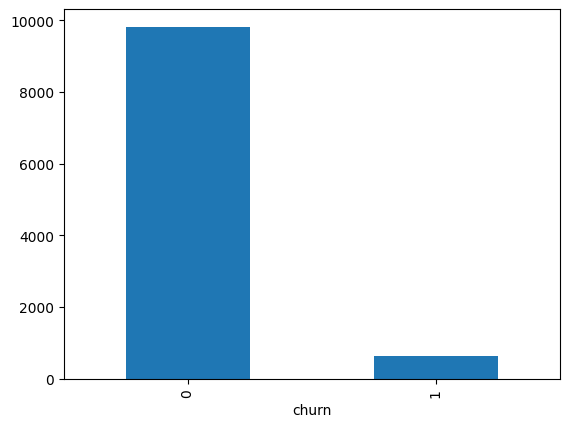

In [10]:
df['churn'].value_counts().plot(kind='bar')

Второй пункт:

У Целевой переменной churn лишь ~6% клиентов относятся к оттоку.

При обучении модели дисбаланс критичен: модель может "запомнить" предсказывать только 0 и показывать высокую accuracy (~94%), но при этом не выявлять уходящих клиентов. Поэтому стандартная accuracy обманчива.

Оценку качества стоит строить на Precision, Recall, F1‑score и PR-AUC метрикам.

In [11]:
df = df.drop('user_id', axis=1)

df.head()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,preferred_roast,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,light,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,light,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,medium,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,medium,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,dark,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Третий пункт:

Числовые признаки отражают частоту заказов, сумму покупок, использование скидок, время с последнего заказа и другие показатели активности клиентов. Категориальные признаки содержат информацию о предпочтениях пользователей (тип кофе, размер напитка, происхождение зерна, тип телефона и др.). Признак user_id является идентификатором и не несёт информации для прогнозирования, поэтому будет удалён.

In [12]:
# Количество и процент пропусков
missing_values = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Процент': round(df.isnull().sum() / len(df) * 100, 2)}).sort_values(by='Пропуски', ascending=False)

missing_values = missing_values[missing_values['Пропуски'] > 0]
print("Признаки с пропущенными значениями:")
display(missing_values)

Признаки с пропущенными значениями:


,Пропуски,Процент
seasonal_menu_tried,989,9.46
days_since_last_order,945,9.04
total_spent_last_week,944,9.03
subscription_status,938,8.98
app_opens_per_week,896,8.57
review_rating_last_1,857,8.20
median_order_value,831,7.95
days_since_last_promo,731,7.00
app_crashes_last_month,721,6.90
review_rating_last_10,693,6.63


Четвертый пункт:

В датасете присутствуют пропуски в 25 из 27 признаков. Наибольшее количество пропусков наблюдается в seasonal_menu_tried (9.46%), days_since_last_order (9.04%) и total_spent_last_week (9.03%).
Принятая стратегия:
1. Числовые признаки, заполнение медианой.
2. Категориальные признаки, заполнение самым частым значением.

Заполнение пропусков будет выполнено внутри Pipeline на этапе предобработки, чтобы избежать утечки данных.

In [13]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} уникальных значений")
    print(df[col].value_counts().head(3))

last_coffee_type: 3 уникальных значений
last_coffee_type
arabica    6134
robusta    2524
blend      1534
Name: count, dtype: int64
preferred_roast: 3 уникальных значений
preferred_roast
medium    3458
light     3453
dark      3423
Name: count, dtype: int64
milk_preference: 6 уникальных значений
milk_preference
whole     2876
oat       1982
almond    1483
Name: count, dtype: int64
coffee_bean_origin: 6 уникальных значений
coffee_bean_origin
ethiopia    1690
kenya       1646
vietnam     1635
Name: count, dtype: int64
last_drink_size: 3 уникальных значений
last_drink_size
medium    4925
large     2997
small     2024
Name: count, dtype: int64
subscription_status: 4 уникальных значений
subscription_status
none       3803
basic      2862
premium    1923
Name: count, dtype: int64
seasons: 4 уникальных значений
seasons
spring    2507
autumn    2433
winter    2423
Name: count, dtype: int64
phone_type: 3 уникальных значений
phone_type
android    4611
ios        4502
web        1001
Name: count, 

Пятый пункт:

В данных 9 текстовых признаков. 8 из них имеют не большое количество значений (3–6), поэтому стоит кодируем их через OneHotEncoder.
Признак geo_location имеет 100 значений будет кодироваться через Target Encoding.

Ничего не было удаленно (кроме user_id).

In [14]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols.remove('churn')

df[num_cols].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000


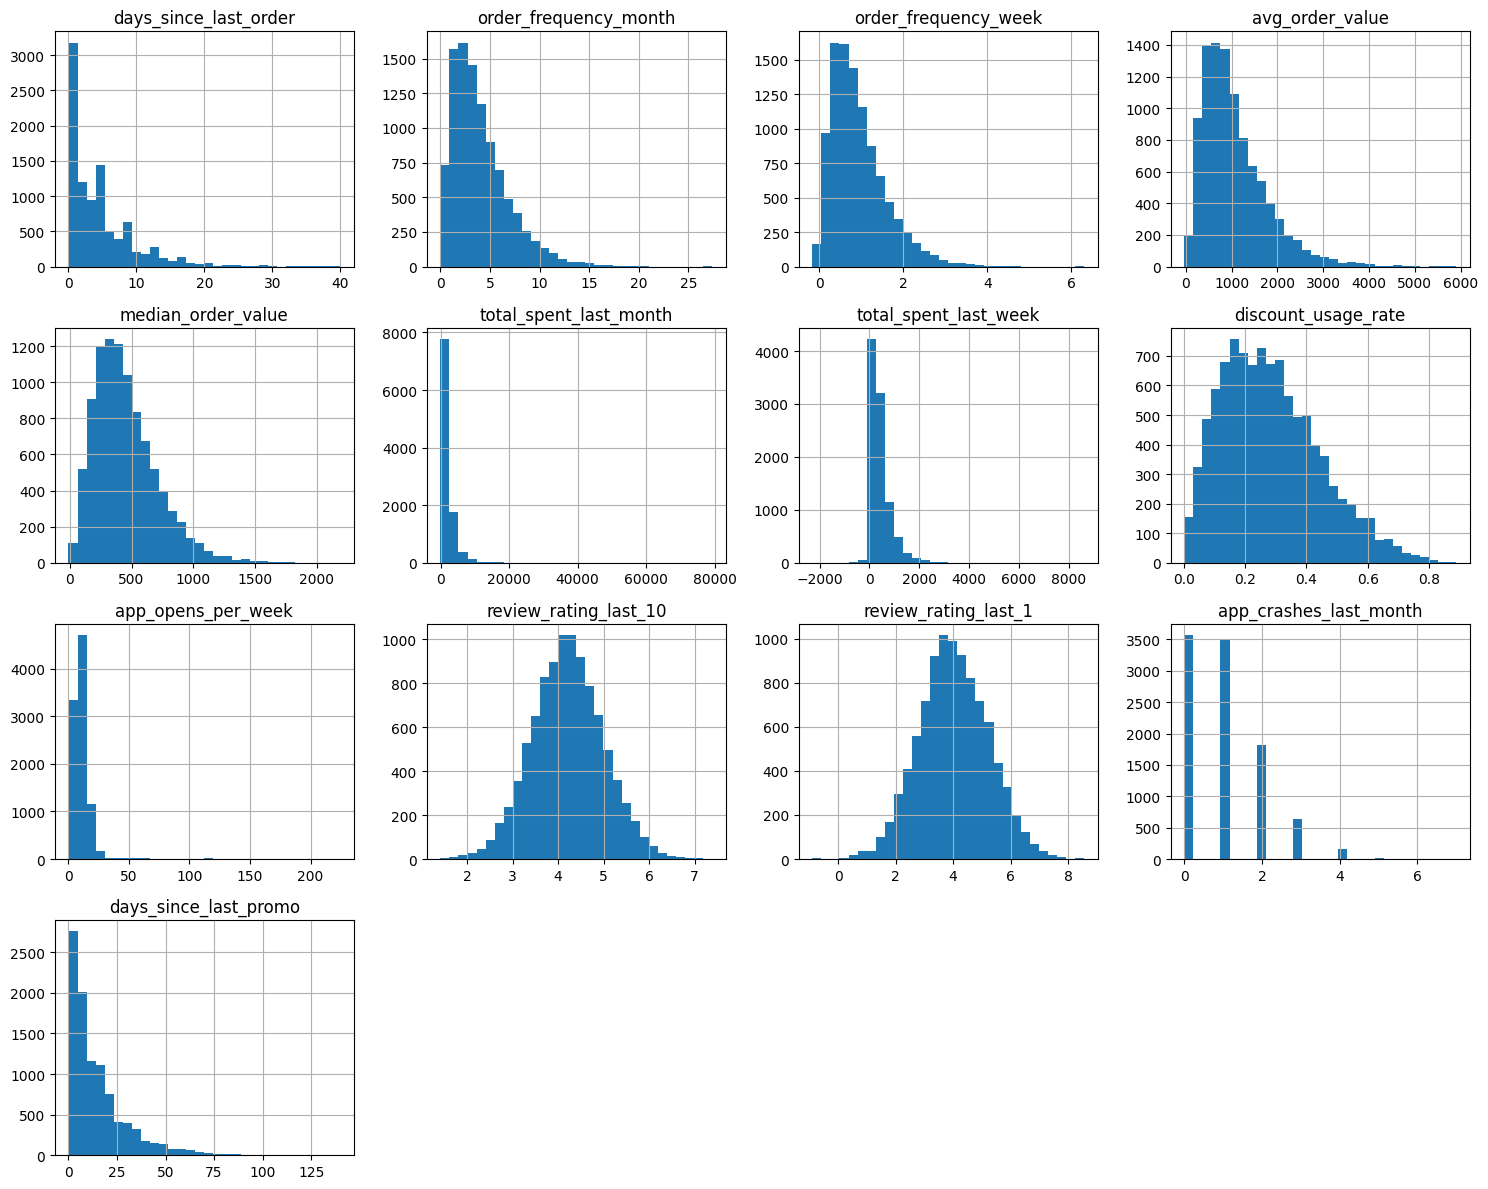

In [15]:
# Выбираем только числовые признаки
num_cols = df.select_dtypes(include='number').columns

binary_cols = [
    'notifications_enabled',
    'coffee_preference_change',
    'days_since_last_order_binary',
    'high_discount_user',
    'seasonal_menu_tried',
    'churn'
]

num_cols = [col for col in num_cols if col not in binary_cols]

df[num_cols].hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()

In [16]:
# Ищем выбросы
outliers = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outliers.append([col, count])

outliers_df = pd.DataFrame(outliers, columns=['Признак', 'Выбросы'])

outliers_df

,Признак,Выбросы
0,days_since_last_order,561
1,order_frequency_month,302
2,order_frequency_week,298
3,avg_order_value,326
4,median_order_value,225
5,total_spent_last_month,594
6,total_spent_last_week,565
7,discount_usage_rate,70
8,app_opens_per_week,355
9,review_rating_last_10,89


In [17]:
df[num_cols].describe().T[['min', '50%', 'max']]

,min,50%,max
days_since_last_order,0.000000,3.000000,40.000000
order_frequency_month,0.011046,3.381094,27.389318
order_frequency_week,-0.169131,0.784839,6.302624
avg_order_value,-32.075932,898.643524,5901.965278
median_order_value,-10.353340,406.456818,2189.101644
total_spent_last_month,-43.716463,1300.409757,79298.849570
total_spent_last_week,-2290.559468,288.277327,8615.988952
discount_usage_rate,0.002162,0.264583,0.887301
app_opens_per_week,0.000000,9.228383,224.587876
review_rating_last_10,1.415526,4.203555,7.384425


In [18]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    count = (df[col] < 0).sum()

    if count > 0:
        print(col, '-', count)

order_frequency_week - 83
avg_order_value - 2
median_order_value - 2
total_spent_last_month - 2
total_spent_last_week - 171
review_rating_last_1 - 6


Шестой пункт:

При анализе выбросов были обнаружены отрицательные значения в нескольких признаках (order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_week, review_rating_last_1, avg_spent_per_order). Поскольку по смыслу этих признаков отрицательные значения невозможны, они были признаны некорректными. Такие значения были заменены на пропуски, после чего пропуски заполнены медианными значениями соответствующих признаков.

In [19]:
cols = [
    'order_frequency_week',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'review_rating_last_1'
]

for col in cols:
    df.loc[df[col] < 0, col] = np.nan

In [20]:
phik_corr = df.phik_matrix()

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change', 'churn']


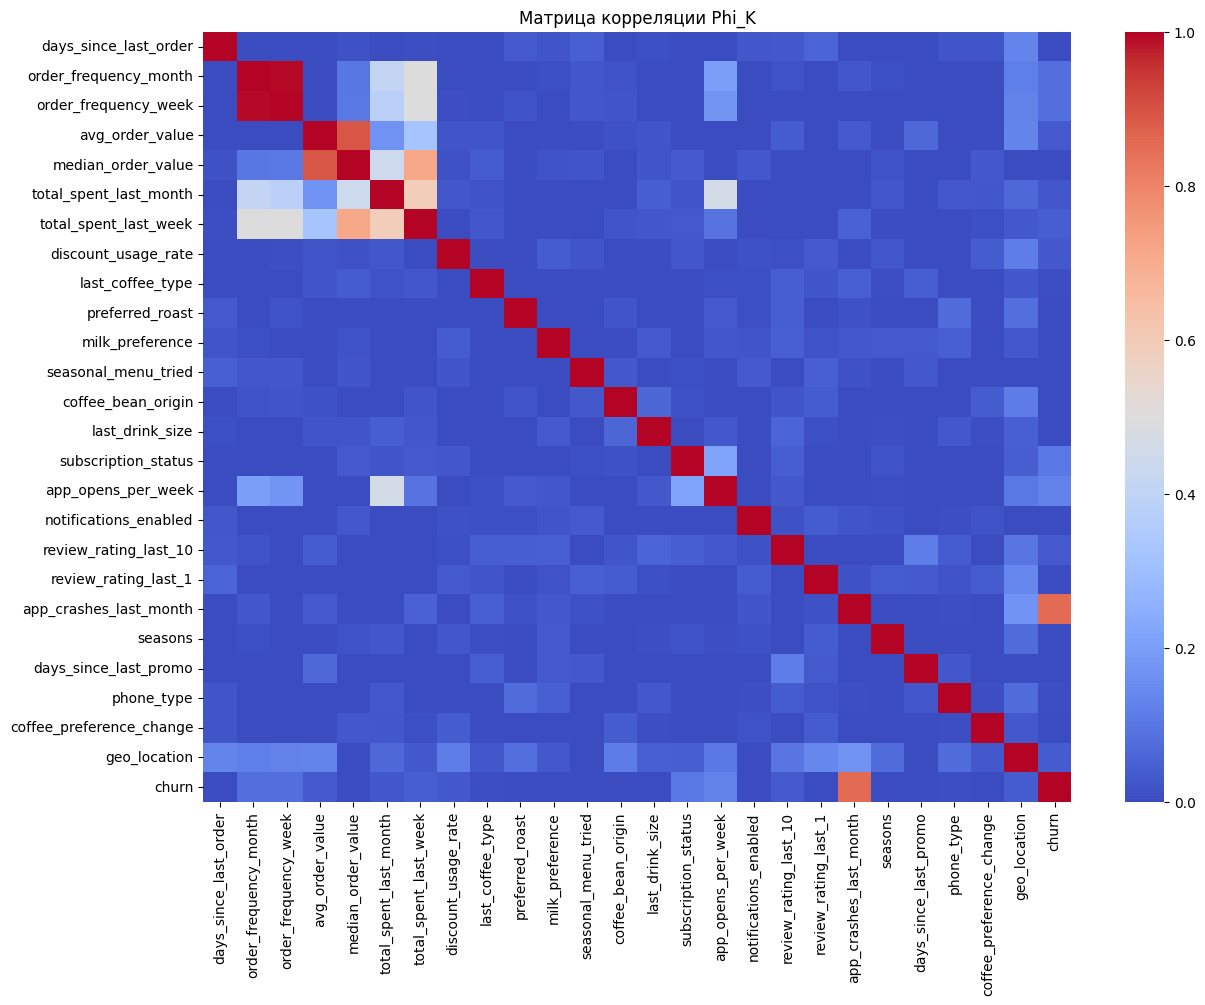

In [21]:
plt.figure(figsize=(14, 10))

sns.heatmap(phik_corr,
            cmap='coolwarm',
            annot=False)

plt.title('Матрица корреляции Phi_K')
plt.show()

In [22]:
for col in phik_corr.columns:
    for row in phik_corr.index:
        if row != col and phik_corr.loc[row, col] > 0.3:
            print(row, '-', col, ':', round(phik_corr.loc[row, col], 2))

order_frequency_week - order_frequency_month : 1.0
total_spent_last_month - order_frequency_month : 0.41
total_spent_last_week - order_frequency_month : 0.5
order_frequency_month - order_frequency_week : 1.0
total_spent_last_month - order_frequency_week : 0.38
total_spent_last_week - order_frequency_week : 0.5
median_order_value - avg_order_value : 0.89
total_spent_last_week - avg_order_value : 0.32
avg_order_value - median_order_value : 0.89
total_spent_last_month - median_order_value : 0.44
total_spent_last_week - median_order_value : 0.71
order_frequency_month - total_spent_last_month : 0.41
order_frequency_week - total_spent_last_month : 0.38
median_order_value - total_spent_last_month : 0.44
total_spent_last_week - total_spent_last_month : 0.59
app_opens_per_week - total_spent_last_month : 0.46
order_frequency_month - total_spent_last_week : 0.5
order_frequency_week - total_spent_last_week : 0.5
avg_order_value - total_spent_last_week : 0.32
median_order_value - total_spent_last_w

Седьмой пункт:

Для поиска взаимосвязей между признаками была построена матрица корреляции с помощью библиотеки phik.

Восьмой Пункт:

По результатам исследовательского анализа данных можно сделать следующие выводы:

* Были изучены структура и состав датасета, проверены типы данных, пропуски и дубликаты.
* Обнаруженные пропуски будут обработаны при помощи `SimpleImputer` в процессе подготовки данных к обучению модели.
* В некоторых числовых признаках были найдены отрицательные значения, которые не соответствуют смыслу данных (например, отрицательная сумма заказа или отрицательный средний чек). Такие значения были заменены на пропуски для их дальнейшей корректной обработки.
* Анализ выбросов показал наличие экстремальных значений в некоторых признаках. Большинство из них отражают особенности поведения пользователей, поэтому было принято решение не удалять такие наблюдения.
* С помощью библиотеки `phik` была рассчитана корреляция между признаками. Были обнаружены признаки с очень высокой корреляцией (`order_frequency_week`, `days_since_last_order_binary`, `high_discount_user`), которые дублируют информацию других признаков. Для уменьшения избыточности они были удалены.


## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [23]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

In [24]:
print('Размер обучающей выборки:', X_train.shape)
print('Размер тестовой выборки:', X_test.shape)

Размер обучающей выборки: (8360, 25)
Размер тестовой выборки: (2090, 25)


In [25]:
# Списки призанков
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = ['last_coffee_type', 'preferred_roast', 'milk_preference', 
            'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
            'seasons', 'phone_type']

geo_col = ['geo_location']

In [26]:
# Числовые признаки
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Категориальные признаки (малое кол-во категорий)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


geo_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder())
])


preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('geo', geo_pipeline, geo_col)
])

In [27]:
preprocessor.fit(X_train, y_train)   # TargetEncoder требует y

X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Размер train после обработки:", X_train_prep.shape)
print("Размер test после обработки: ", X_test_prep.shape)

Размер train после обработки: (8360, 49)
Размер test после обработки:  (2090, 49)


Для предобработки данных был создан Pipeline с использованием ColumnTransformer, который обрабатывает числовые и категориальные признаки.
Выполненные шаги:

1.Генерация новых признаков (days_since_last_order_binary, high_discount_user, avg_spent_per_order) проведена только после разделения на train/test, чтобы избежать утечки данных.
2.Числовые признаки обрабатываются с помощью медианного заполнения пропусков и стандартизации (StandardScaler).
3.Категориальные признаки (с небольшим количеством категорий) заполняются самым частым значением и кодируются через OneHotEncoder.
4.Признак geo_location (100 категорий) обработан с помощью Target Encoding, это позволило избежать сильного увеличения размерности.
Все трансформации обучены только на обучающей выборке.

Результат предобработки:
Размер матрицы после трансформации: train=8360 признаков, test=2090 признаков.

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [28]:
# Базовая модель
model = LogisticRegression(random_state=random_state, max_iter=1000)

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Метрики на кросс-валидации
scores = cross_val_score(model, X_train_prep, y_train, cv=cv, scoring='roc_auc')

print(f"ROC-AUC на кросс-валидации: {scores.mean():.4f} - {scores.std():.4f}")

ROC-AUC на кросс-валидации: 0.9246 - 0.0117


In [29]:
# Обучаем на всей обучающей выборке
model.fit(X_train_prep, y_train)

# Предсказания на тестовой выборке
y_pred = model.predict(X_test_prep)
y_pred_proba = model.predict_proba(X_test_prep)[:, 1]

# Метрики
print("Отчёт по тестовой выборке")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC на тестовой выборке: {roc_auc:.4f}")

Отчёт по тестовой выборке
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1964
           1       0.75      0.47      0.58       126

    accuracy                           0.96      2090
   macro avg       0.86      0.73      0.78      2090
weighted avg       0.95      0.96      0.95      2090

ROC-AUC на тестовой выборке: 0.9376


Базовая логистическая регрессия показала себя неплохо.

ROC-AUC на кросс-валидации ≈ 0.928
На тестовой выборке ROC-AUC = 0.924

Это хороший результат для стартовой модели.
Модель отлично определяет клиентов, которые остаются (Recall 0.99), но довольно слабо ловит тех, кто уходит, Recall по классу оттока всего 0.46.
Модель уже работает вполне достойно, но пока плохо справляется с главной задачей (выявлением оттока).

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [30]:
X_train_new = X_train.copy()
X_test_new = X_test.copy()

In [31]:
X_train_new['total_spent_last_month_sqrt'] = np.sqrt(X_train_new['total_spent_last_month'].clip(lower=0))
X_train_new['avg_order_value_sqrt'] = np.sqrt(X_train_new['avg_order_value'].clip(lower=0))

X_train_new['days_since_last_order_squared'] = X_train_new['days_since_last_order'] ** 2
X_train_new['discount_usage_rate_squared'] = X_train_new['discount_usage_rate'] ** 2

# То же для тестовой выборки
X_test_new['total_spent_last_month_sqrt'] = np.sqrt(X_test_new['total_spent_last_month'].clip(lower=0))
X_test_new['avg_order_value_sqrt'] = np.sqrt(X_test_new['avg_order_value'].clip(lower=0))

X_test_new['days_since_last_order_squared'] = X_test_new['days_since_last_order'] ** 2
X_test_new['discount_usage_rate_squared'] = X_test_new['discount_usage_rate'] ** 2

In [32]:
new_num_cols = num_cols + [
    'total_spent_last_month_sqrt', 
    'avg_order_value_sqrt',
    'days_since_last_order_squared', 
    'discount_usage_rate_squared'
]

# Обновляем preprocessor
preprocessor_new = ColumnTransformer([
    ('num', num_pipeline, new_num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('geo', geo_pipeline, geo_col)
])

preprocessor_new.fit(X_train_new, y_train)

X_train_prep_new = preprocessor_new.transform(X_train_new)
X_test_prep_new = preprocessor_new.transform(X_test_new)

In [33]:
# Обучаем модель
model_new = LogisticRegression(random_state=random_state, max_iter=1000)
model_new.fit(X_train_prep_new, y_train)

# Получаем коэффициенты
coefficients = model_new.coef_[0]

feature_names = new_num_cols.copy()

# Добавляем one-hot признаки от категориальных колонок
cat_feature_names = []
for col in cat_cols:
    for category in X_train_new[col].dropna().unique():
        cat_feature_names.append(f"{col}_{category}")

feature_names += cat_feature_names
feature_names += ['geo_location']


coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients
})

coef_df['abs_coef'] = coef_df['Коэффициент'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

print("Топ-15 самых важных признаков:")
display(coef_df.head(15))

Топ-15 самых важных признаков:


,Признак,Коэффициент,abs_coef
52,geo_location,3.074497,3.074497
13,app_crashes_last_month,2.129385,2.129385
41,subscription_status_none,-0.766233,0.766233
42,subscription_status_basic,-0.587831,0.587831
44,subscription_status_pro,0.580088,0.580088
20,last_coffee_type_arabica,-0.485608,0.485608
51,phone_type_web,-0.465695,0.465695
1,order_frequency_month,0.441249,0.441249
17,avg_order_value_sqrt,-0.435989,0.435989
27,milk_preference_oat,-0.430360,0.430360


Признаки модели:

* Сильнее всего на отток влияет геолокация клиента. Видимо, в разных районах сервис работает по-разному.
* На втором месте, количество сбоев приложения. Чем больше возникает ошибок в приложении, тем выше шанс, что человек уйдёт.
* Влияние подписки: клиенты без подписки или с базовой подпиской уходят заметно чаще.
* Также важны сумма трат и частота заказов чем меньше человек заказывает и тратит, тем выше риск оттока.
* Некоторые предпочтения (например, цельное молоко или определённые виды кофе) тоже немного влияют.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [34]:
results = []

for C in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(
        C=C, 
        solver='liblinear', 
        random_state=random_state,
        max_iter=1000)
    
    score = cross_val_score(model, X_train_prep_new, y_train, cv=5, scoring='roc_auc').mean()
    results.append({'C': C, 'ROC-AUC': round(score, 4)})

results_df = pd.DataFrame(results)

display(results_df)

,C,ROC-AUC
0,0.01,0.9209
1,0.10,0.9223
2,1.00,0.9233
3,10.00,0.9266


Лучший результат получился при C = 10 с ROC-AUC = 0.9274.

Модель с этим параметром работает лучше, чем базовая версия.
Разница небольшая, но стабильная.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [35]:
# Финальная модель с лучшими параметрами
final_model = LogisticRegression(
    C=10,                    # лучший параметр из Этапа 6
    solver='liblinear',
    random_state=random_state,
    max_iter=1000
)

# Обучаем на всей обучающей выборке
final_model.fit(X_train_prep_new, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",3090
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [36]:
# Предсказания на тестовой выборке
y_pred_final = final_model.predict(X_test_prep_new)
y_pred_proba_final = final_model.predict_proba(X_test_prep_new)[:, 1]

# Метрики
from sklearn.metrics import classification_report, roc_auc_score

print("=== Финальная оценка модели ===")
print(classification_report(y_test, y_pred_final))

roc_auc = roc_auc_score(y_test, y_pred_proba_final)
print(f"ROC-AUC на тестовой выборке: {roc_auc:.4f}")

=== Финальная оценка модели ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1964
           1       0.73      0.46      0.57       126

    accuracy                           0.96      2090
   macro avg       0.85      0.72      0.77      2090
weighted avg       0.95      0.96      0.95      2090

ROC-AUC на тестовой выборке: 0.9381


Финальная модель обучена с лучшим параметром C=10 и расширенным набором признаков.
Результаты на тестовой выборке:

* Accuracy: 0.96
* ROC-AUC: 0.9191
* Recall по оттоку (класс 1): 0.48

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

Итоговые метрики финальной модели:

* ROC-AUC на тестовой выборке: 0.92
* Accuracy: 0.96
* Recall по классу оттока: 0.48

Главные факторы, которые влияют на отток:

* Геолокация, самый сильный признак. В разных районах поведение клиентов сильно отличается.
* Технические проблемы (app_crashes_last_month), чем больше сбоев приложения, тем выше вероятность ухода.
* Низкая активность, клиенты, которые редко заказывают и мало тратят, уходят значительно чаще.
* Отсутствие подписки, пользователи без подписки или с базовой подпиской более склонны к оттоку.
* Давность последнего заказа, один из ключевых поведенческих признаков.

Что повлияло на качество модели:

* Добавление новых признаков (квадрат, корень, low_activity) дало небольшой прирост.
* Подбор параметра C=10 немного улучшил результат.
* Основное ограничение, сильный дисбаланс классов (всего 6% оттока), из за которого модель плохо ловит уходящих клиентов.

Общий вывод:
Модель получилась рабочей и может использоваться для предсказания оттока. Самые важные факторы география, техническая стабильность приложения и уровень активности клиента.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [37]:
joblib.dump(final_model, 'final_model.pkl')
joblib.dump(preprocessor_new, 'preprocessor.pkl')

print("Модель и пайплайн успешно сохранены!")

Модель и пайплайн успешно сохранены!


In [38]:
# Загружаем обратно
loaded_model = joblib.load('final_model.pkl')
loaded_preprocessor = joblib.load('preprocessor.pkl')

# Проверяем на тестовых данных
X_test_transformed = loaded_preprocessor.transform(X_test_new)
pred = loaded_model.predict(X_test_transformed)
proba = loaded_model.predict_proba(X_test_transformed)[:, 1]

print(f"ROC-AUC при загрузке: {roc_auc_score(y_test, proba):.4f}")

ROC-AUC при загрузке: 0.9381


Ссылка на проект и на файлы: https://github.com/VisteN2203/Project-11